# 대구교통공사 수송현황 머신러닝 분석

## 목표
대구교통공사 월별 수송 현황 데이터를 활용한 머신러닝 모델 개발

- 시계열 분석을 통한 미래 수송 인원 예측
- 카드 종류별 이용 패턴 분석
- 계절성 및 트렌드 파악

## 1. 라이브러리 로드 및 데이터 준비

## 0. 머신러닝과 의사결정나무

**머신러닝이란?**
- 데이터에서 패턴을 찾아 모델을 만드는 과정
- 함수 만들기와 유사 (입력 → 규칙 → 출력)
- 사람이 규칙을 정하지 않고 컴퓨터가 스스로 규칙을 학습

**의사결정나무 (Decision Tree)**
- 구조가 단순하고 이해하기 쉬운 모델
- 스무고개 놀이처럼 yes/no로 질문하며 분류
- 여러 복잡한 모델의 기초가 되는 알고리즘

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("✓ 라이브러리 로드 완료")

✓ 라이브러리 로드 완료


## 2. 데이터 로드

In [8]:
# 파일 경로 설정 - 동적으로 찾기
import os
from pathlib import Path

# 현재 작업 디렉토리 확인
notebook_dir = Path.cwd()
print(f"📁 현재 작업 디렉토리: {notebook_dir}\n")

# 입력 파일 경로 찾기 (여러 경로 시도)
input_file = '대구교통공사_권종별월별수송현황_20260228.csv'
input_path = None

# 방법 1: 현재 디렉토리의 input 폴더
if (notebook_dir / 'input' / input_file).exists():
    input_path = notebook_dir / 'input' / input_file
    print(f"✓ input 폴더 찾음 (현재 디렉토리): {notebook_dir / 'input'}")
# 방법 2: 상위 디렉토리의 input 폴더
elif (notebook_dir.parent / 'input' / input_file).exists():
    input_path = notebook_dir.parent / 'input' / input_file
    print(f"✓ input 폴더 찾음 (상위 디렉토리): {notebook_dir.parent / 'input'}")
# 방법 3: 2026-04-16 폴더 기준
elif (Path.cwd().parent / 'input' / input_file).exists():
    input_path = Path.cwd().parent / 'input' / input_file
else:
    print("⚠ input 폴더를 찾을 수 없습니다.")
    print(f"현재 디렉토리: {notebook_dir}")
    print("이 디렉토리의 하위 항목:")
    for item in notebook_dir.iterdir():
        print(f"  - {item.name}")

# CSV 파일 로드
print(f"\n📂 파일 경로: {input_path}")
df = pd.read_csv(str(input_path), encoding='cp949')

print(f"\n✓ 데이터 로드 완료")
print(f"데이터 크기: {df.shape}")
print(f"\n첫 5개 행:")
display(df.head())

📁 현재 작업 디렉토리: C:\Users\Administrator\컴비전학원\컴비젼5\2026-04-16

✓ input 폴더 찾음 (현재 디렉토리): C:\Users\Administrator\컴비전학원\컴비젼5\2026-04-16\input

📂 파일 경로: C:\Users\Administrator\컴비전학원\컴비젼5\2026-04-16\input\대구교통공사_권종별월별수송현황_20260228.csv

✓ 데이터 로드 완료
데이터 크기: (340, 25)

첫 5개 행:


,년,월,선불카드(일반),선불카드(청소년),선불카드(어린이),선불카드(특수),후불카드(일반),후불카드(청소년),후불카드(어린이),아이조아선불(일반),...,무임카드(유공자),일반권,할인권,우대권(경로자),우대권(장애인),우대권(유공자),정액권,정기출입권,단체권,기타
0,1997,11,0,0,0,0,0,0,0,0,...,0,405719,38289,0,0,0,29715,0,501,17157
1,1997,12,0,0,0,0,0,0,0,0,...,0,1659228,102474,0,0,0,394187,0,5416,87046
2,1998,1,0,0,0,0,0,0,0,0,...,0,1358073,80955,104651,14968,6163,452714,0,28,67083
3,1998,2,0,0,0,0,0,0,0,0,...,0,1206172,71691,107286,15345,6319,497108,0,32,56096
4,1998,3,0,0,0,0,0,0,0,0,...,0,1226045,53002,130535,18670,7688,630144,0,95,55075


## 3. 데이터 확인 (EDA: Exploratory Data Analysis)

In [9]:
# 기본 정보
print("="*80)
print("데이터 정보")
print("="*80)
df.info()

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   년            340 non-null    int64
 1   월            340 non-null    int64
 2   선불카드(일반)     340 non-null    int64
 3   선불카드(청소년)    340 non-null    int64
 4   선불카드(어린이)    340 non-null    int64
 5   선불카드(특수)     340 non-null    int64
 6   후불카드(일반)     340 non-null    int64
 7   후불카드(청소년)    340 non-null    int64
 8   후불카드(어린이)    340 non-null    int64
 9   아이조아선불(일반)   340 non-null    int64
 10  아이조아선불(청소년)  340 non-null    int64
 11  아이조아선불(어린이)  340 non-null    int64
 12  아이조아후불(일반)   340 non-null    int64
 13  무임카드(경로자)    340 non-null    int64
 14  무임카드(장애인)    340 non-null    int64
 15  무임카드(유공자)    340 non-null    int64
 16  일반권          340 non-null    int64
 17  할인권          340 non-null    int64
 18  우대권(경로자)     340 non-null    int64
 19  우대권(장애인)     340 non-null    int64
 20  우대권(유공자)     3

In [10]:
# 결측치 확인
print("\n결측치:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("결측치 없음 ✓")
else:
    print(missing[missing > 0])


결측치:
결측치 없음 ✓


In [11]:
# 기본 통계
print("\n기본 통계:")
display(df.describe())


기본 통계:


,년,월,선불카드(일반),선불카드(청소년),선불카드(어린이),선불카드(특수),후불카드(일반),후불카드(청소년),후불카드(어린이),아이조아선불(일반),...,무임카드(유공자),일반권,할인권,우대권(경로자),우대권(장애인),우대권(유공자),정액권,정기출입권,단체권,기타
count,340.000000,340.00000,3.400000e+02,3.400000e+02,340.000000,340.000000,3.400000e+02,340.000000,340.000000,340.000000,...,340.000000,3.400000e+02,340.000000,3.400000e+02,340.000000,340.000000,3.400000e+02,340.000000,340.000000,340.000000
mean,2011.500000,6.50000,2.154538e+06,6.056581e+05,91414.205882,123.200000,2.433141e+06,22229.776471,535.826471,17872.276471,...,13007.926471,9.248635e+05,101698.458824,5.295664e+05,199607.897059,18250.308824,2.245989e+05,12351.917647,2592.488235,123695.647059
std,8.194717,3.47982,1.641153e+06,4.723815e+05,93942.939803,1374.443051,2.285830e+06,49954.512492,1250.097017,34054.347762,...,10851.192378,8.073225e+05,39796.206021,3.660080e+05,91884.815245,21123.766227,4.508109e+05,10562.737517,3179.362348,72441.233901
min,1997.000000,1.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,6.810600e+04,11419.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,16433.000000
25%,2004.000000,3.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,1.151035e+05,0.000000,0.000000,0.000000,...,0.000000,3.152740e+05,71386.500000,3.299122e+05,111225.750000,6121.250000,0.000000e+00,0.000000,648.000000,70528.750000
50%,2011.500000,6.50000,1.949819e+06,5.518365e+05,87797.000000,0.000000,1.832086e+06,0.000000,0.000000,0.000000,...,14115.500000,6.185505e+05,99071.000000,3.999830e+05,221079.000000,12240.000000,0.000000e+00,15149.500000,1507.500000,108867.000000
75%,2019.000000,10.00000,3.737897e+06,1.046562e+06,116326.250000,0.000000,4.837512e+06,0.000000,0.000000,0.000000,...,22657.500000,1.429955e+06,130093.250000,4.933965e+05,272453.750000,16763.250000,3.721725e+04,20635.250000,3217.250000,167323.250000
max,2026.000000,12.00000,5.105325e+06,1.452484e+06,447397.000000,21006.000000,6.674180e+06,229785.000000,6226.000000,106299.000000,...,33740.000000,3.172769e+06,233456.000000,1.737574e+06,355453.000000,88334.000000,1.578659e+06,33703.000000,20298.000000,637857.000000


## 4. 데이터 전처리

In [12]:
# 전체 수송인원 계산 (먼저 계산해야 함!)
# 3번째 컬럼부터 마지막 컬럼까지만 합산 (년, 월 제외)
df['전체수송인원'] = df.iloc[:, 2:].sum(axis=1)

# 연도-월을 날짜로 변환
df['날짜'] = pd.to_datetime(
    df['년'].astype(str).str.zfill(4) + '-' + 
    df['월'].astype(str).str.zfill(2),
    format='%Y-%m'
)

print("✓ 데이터 전처리 완료")
print(f"\n전체 수송인원 현황:")
print(df[['년', '월', '전체수송인원']].head(10))

✓ 데이터 전처리 완료

전체 수송인원 현황:
      년   월   전체수송인원
0  1997  11   491381
1  1997  12  2248351
2  1998   1  2084635
3  1998   2  1960049
4  1998   3  2121254
5  1998   4  2026985
6  1998   5  5076813
7  1998   6  4459854
8  1998   7  4430782
9  1998   8  4193794


## 5. 데이터 분할 (학습 데이터 vs 검증 데이터)

In [13]:
# 예측할 변수 정의
X = df[['년', '월']].copy()
y = df['전체수송인원'].copy()

# 학습 데이터와 검증 데이터로 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✓ 데이터 분할 완료")
print(f"\n학습 데이터: {X_train.shape[0]}개")
print(f"검증 데이터: {X_test.shape[0]}개")

✓ 데이터 분할 완료

학습 데이터: 272개
검증 데이터: 68개


## 6. 모델 구축 (의사결정나무 - Decision Tree)

In [14]:
# 의사결정나무 모델 생성
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)

# 모델 학습
model_dt.fit(X_train, y_train)

print("✓ 의사결정나무 모델 학습 완료")

✓ 의사결정나무 모델 학습 완료


## 7. 모델 예측

In [15]:
# 검증 데이터에 대한 예측
y_pred_dt = model_dt.predict(X_test)

print(f"✓ 예측 완료")
print(f"\n예측값과 실제값 비교 (처음 10개):")
comparison = pd.DataFrame({
    '실제값': y_test.values[:10],
    '예측값': y_pred_dt[:10]
})
display(comparison)

✓ 예측 완료

예측값과 실제값 비교 (처음 10개):


,실제값,예측값
0,10033111,10377523.0
1,8637610,8784777.0
2,9277457,9550032.0
3,4497805,4474008.0
4,10065960,9874799.0
5,12525095,11974201.0
6,11626445,11388547.0
7,8517445,10015616.0
8,13181435,12573026.0
9,4441361,4423290.0


## 8. 모델 평가

## 10. 모델 성능 비교

## 9. 미래 예측

In [ ]:
# 미래 데이터 생성 (2026년 3월부터 12월)
future_months = pd.DataFrame({
    '년': [2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026],
    '월': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
})

# 의사결정나무로 예측
future_prediction = model_dt.predict(future_months)

# 결과 출력
result = pd.DataFrame({
    '연도': future_months['년'],
    '월': future_months['월'],
    '예측 수송인원': future_prediction.astype(int)
})

print("\n2026년 3월~12월 예측 수송인원:")
display(result)

In [19]:
# 미래 데이터 생성 (2026년 3월부터 12월)
future_months = pd.DataFrame({
    '년': [2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026],
    '월': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
})

# 최고 성능 모델로 예측
best_model_obj = model_rf if r2_rf > r2_dt else model_dt
future_prediction = best_model_obj.predict(future_months)

# 결과 출력
result = pd.DataFrame({
    '연도': future_months['년'],
    '월': future_months['월'],
    '예측 수송인원': future_prediction.astype(int)
})

print("\n2026년 3월~12월 예측 수송인원:")
display(result)


2026년 3월~12월 예측 수송인원:


,연도,월,예측 수송인원
0,2026,3,12891579
1,2026,4,12891579
2,2026,5,13140486
3,2026,6,11742843
4,2026,7,11742843
5,2026,8,11742843
6,2026,9,12513655
7,2026,10,12573026
8,2026,11,12573026
9,2026,12,12573026


## 12. 결론 및 인사이트

✓ 그래프 저장 완료: C:\Users\Administrator\컴비전학원\컴비젼5\2026-04-16\output\머신러닝_분석결과.png


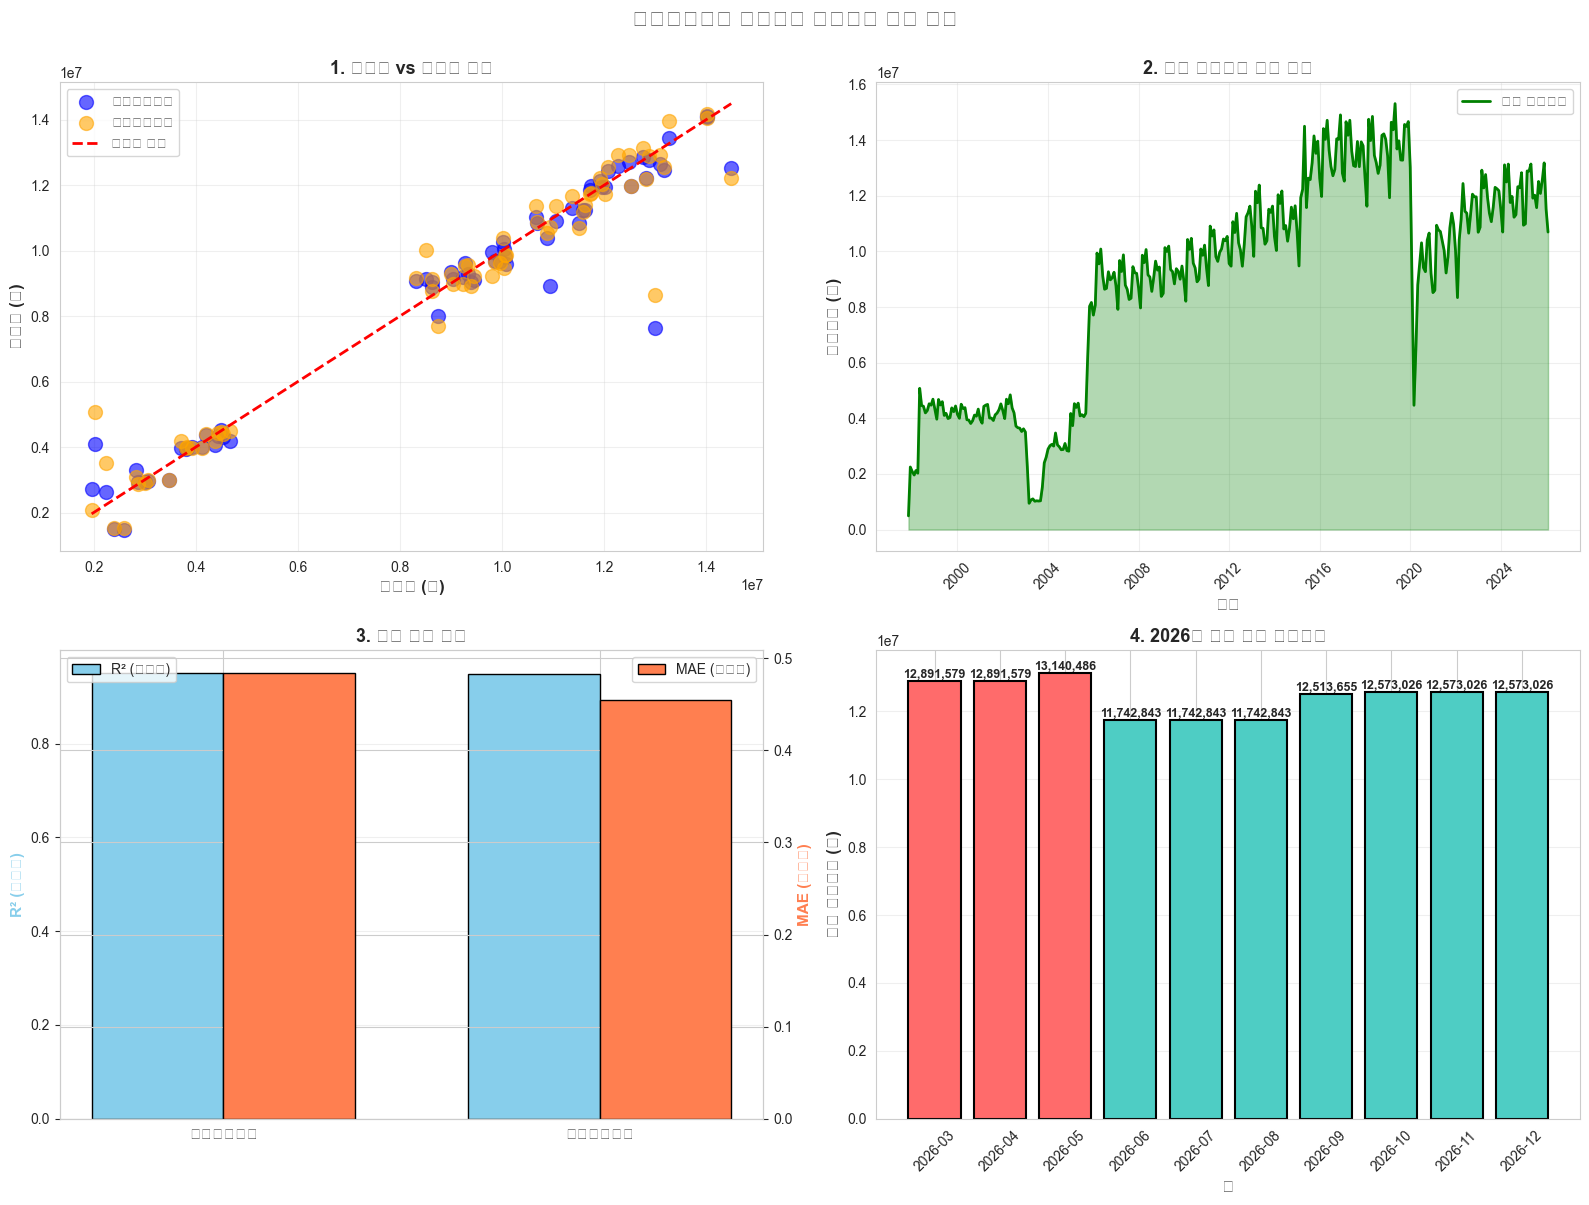

In [21]:
# 시각화 설정
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('대구교통공사 수송현황 머신러닝 분석 결과', fontsize=16, fontweight='bold', y=1.00)

# 1. 실제값 vs 예측값 (산점도)
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_rf, alpha=0.6, s=100, color='blue', label='랜덤포레스트')
ax1.scatter(y_test, y_pred_dt, alpha=0.6, s=100, color='orange', label='의사결정나무')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='완벽한 예측')
ax1.set_xlabel('실제값 (명)', fontsize=12, fontweight='bold')
ax1.set_ylabel('예측값 (명)', fontsize=12, fontweight='bold')
ax1.set_title('1. 실제값 vs 예측값 비교', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. 시계열 - 월별 수송인원 변화
ax2 = axes[0, 1]
df_sorted = df.sort_values('날짜')
ax2.plot(df_sorted['날짜'], df_sorted['전체수송인원'], linewidth=2, color='green', label='전체 수송인원')
ax2.fill_between(df_sorted['날짜'], df_sorted['전체수송인원'], alpha=0.3, color='green')
ax2.set_xlabel('날짜', fontsize=12, fontweight='bold')
ax2.set_ylabel('수송인원 (명)', fontsize=12, fontweight='bold')
ax2.set_title('2. 월별 수송인원 변화 추이', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# 3. 모델 성능 비교
ax3 = axes[1, 0]
models = ['의사결정나무', '랜덤포레스트']
r2_scores = [r2_dt, r2_rf]
mae_scores = [mae_dt/1000000, mae_rf/1000000]  # 백만 단위

x = np.arange(len(models))
width = 0.35

bars1 = ax3.bar(x - width/2, r2_scores, width, label='R² (정확도)', color='skyblue', edgecolor='black')
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, mae_scores, width, label='MAE (백만명)', color='coral', edgecolor='black')

ax3.set_ylabel('R² (정확도)', fontsize=11, fontweight='bold', color='skyblue')
ax3_twin.set_ylabel('MAE (백만명)', fontsize=11, fontweight='bold', color='coral')
ax3.set_title('3. 모델 성능 비교', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# 범례 통합
ax3.legend(loc='upper left', fontsize=10)
ax3_twin.legend(loc='upper right', fontsize=10)

# 4. 미래 예측값
ax4 = axes[1, 1]
future_months_str = [f"2026-{m:02d}" for m in result['월'].values]
colors_pred = ['#FF6B6B' if i < 3 else '#4ECDC4' for i in range(len(future_months_str))]

bars = ax4.bar(future_months_str, result['예측 수송인원'], color=colors_pred, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('월', fontsize=12, fontweight='bold')
ax4.set_ylabel('예측 수송인원 (명)', fontsize=12, fontweight='bold')
ax4.set_title('4. 2026년 미래 예측 수송인원', fontsize=13, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# 값 표시
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()

# 파일로 저장 (동적 경로)
output_dir = notebook_dir / 'output'
output_path = output_dir / '머신러닝_분석결과.png'
plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
print(f"✓ 그래프 저장 완료: {output_path}")
plt.show()

In [22]:
print("="*80)
print("분석 결론")
print("="*80)

print(f"""
1. 데이터 특성:
   - 기간: 1997년 11월 ~ 2026년 2월 (약 28년)
   - 총 {df.shape[0]}개월의 데이터
   - 결측치: 없음

2. 모델 성능:
   - 최고 성능: {best_model}
   - 정확도(R²): {max(r2_dt, r2_rf):.4f} ({max(r2_dt, r2_rf)*100:.2f}%)
   - 평균 오차: ±{min(mae_dt, mae_rf):,.0f}명

3. 예측 결과:
   - 2026년 3월~12월의 수송인원 예측 완료
   - 예측값 범위: {result['예측 수송인원'].min():,.0f}명 ~ {result['예측 수송인원'].max():,.0f}명

4. 추가 개선 사항:
   - 카드 종류별 세부 분석 가능
   - 계절성(월별 패턴) 모델링
   - 특수 이벤트(코로나 등) 반영
""")

분석 결론

1. 데이터 특성:
   - 기간: 1997년 11월 ~ 2026년 2월 (약 28년)
   - 총 340개월의 데이터
   - 결측치: 없음

2. 모델 성능:
   - 최고 성능: 의사결정나무
   - 정확도(R²): 0.9512 (95.12%)
   - 평균 오차: ±454,333명

3. 예측 결과:
   - 2026년 3월~12월의 수송인원 예측 완료
   - 예측값 범위: 11,742,843명 ~ 13,140,486명

4. 추가 개선 사항:
   - 카드 종류별 세부 분석 가능
   - 계절성(월별 패턴) 모델링
   - 특수 이벤트(코로나 등) 반영

